In [1]:
print("Hello!")

Hello!


<img src="rat.jpg.png" width="500">

# Rat Olfactory Bulb Electrophysiology Dataset
## Overview
This dataset contains electrophysiological recordings from the olfactory bulb of an adult rat using 8×8 microelectrode array.
The recording captures 11 minutes sampled at 30 kHz from 64 channel.

The data are organized as a continuous recording with shape:
```text
(21,150,000 samples, 64 channels)
```

- Sampling frequency: 30,000 Hz
- Number of channels: 64
- Electrode layout: 8 × 8 microelectrode array
- Recording duration: approximately 705 seconds (~11 minutes)

The dataset includes:

- Continuous recording
- Spike times 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neo
from scipy.signal import spectrogram
import mne
from neo.io import NixIO

## Data Structure

1. Block
2. Segment
3. Analog Signal (64 channels)
3. SpikeTrain (unit_32)
3. SpikeTrain (unit_36)
3. SpikeTrain (unit_38)



# Block

In [138]:
with NixIO("rat_retreat_meta_1kHz.nix", mode="ro") as io:
    block_check = io.read_block()

seg_check = block_check.segments[0]

print(block_check.description)
print(seg_check.description)

for st in seg_check.spiketrains:
    print(st.name, st.annotations)

# Segment

In [139]:
seg = block_loaded.segments[0]
print(seg)

# Analog Signal

In [140]:
sig = seg.analogsignals[0]

In [164]:
sig

AnalogSignal with 64 channels of length 21150000; units V; datatype float64
name: 'continuous_signal'
annotations: {'nix_name': 'neo.analogsignal.6ec8c4a4b75646458bb178ea393b4fb7'}
sampling rate: 30000.0 Hz
time: 0.0 s to 705.0 s

In [141]:
print(sig.shape)

(21150000, 64)


In [142]:
print(sig.sampling_rate)

30000.0 Hz


## Experimental Design

The recording consists of three phases:

1. **Baseline activity**
   
   Activity before ketamine administration.

2. **Ketamine administration**
   
   Systemic ketamine injection.

3. **Post-ketamine activity**
   
   Activity recorded following ketamine administration.




In [143]:
signal = np.asarray(sig[:, 18]).squeeze() #example channel

In [144]:
fs = float(sig.sampling_rate)

In [145]:
times = np.arange(len(signal)) / fs

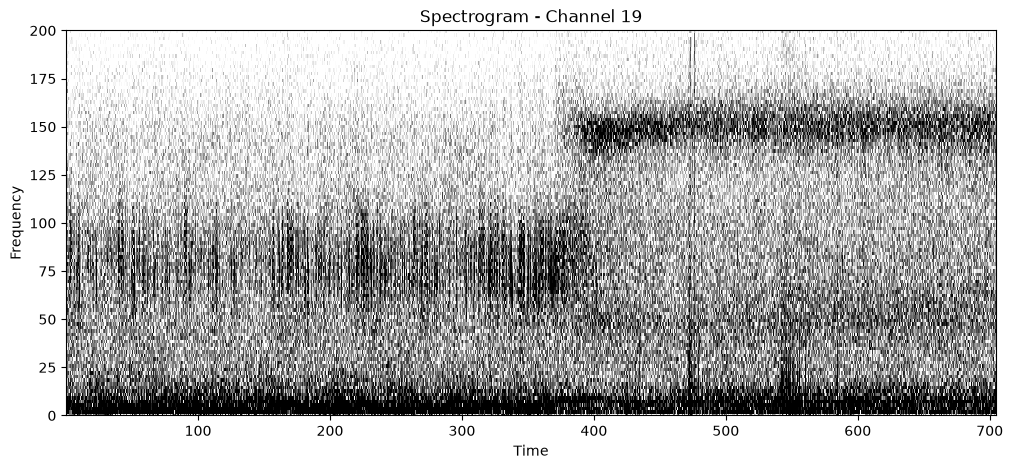

In [85]:
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=16384)
power = 10 * np.log10(Sxx+1e-20)
plt.figure(figsize=(12, 5))
plt.pcolormesh(
    t,
    f,
    power,
    shading="auto",
    cmap="Greys",
    vmin=-115,
    vmax=-95
)
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectrogram - Channel 19")
plt.show()

The spectrogram shows gamma-band activity during the baseline period. 
Following ketamine administration, there is an increase in high-frequency oscillation power around 150 Hz.
It is a marked change in olfactory bulb network dynamics after keramine manipulation.

In [175]:
signal = np.asarray(sig[:, 19]).squeeze() # example channel from 0-63 

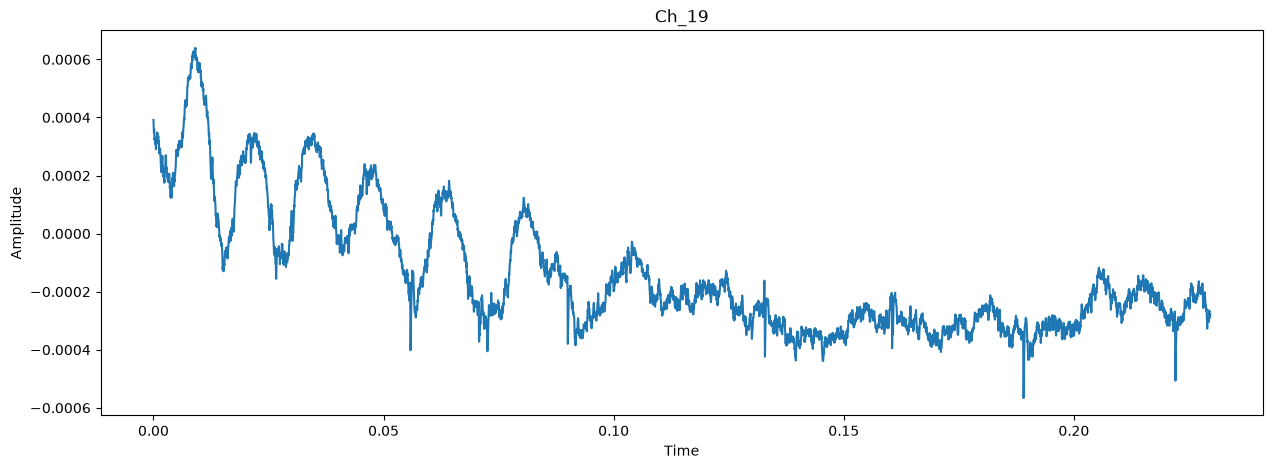

In [176]:
plt.figure(figsize=(15, 5))
plt.plot(
    times[0:6890],
    signal[0:6890]
)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Ch_19")
plt.show()

My goal: understand single unit properties

I would like to use this dataset to learn how to explore and characterize neuronal spike trains. 
- basic spiking statistics such as firing rates, inter-spike interval distributions, and the Fano factor
- examine the relationship between spiking activity and network oscillations observed in the local field potential.
The recording contains a baseline period dominated by gamma-band activity and a ketamine period HFO ~150 Hz. the question is, how neuronal firing patterns relate to different oscillatory states?

My one idea: PCA
**Apply PCA to the 11-minute recording (baseline + ketamine)**

For example: if I apply PCA ,the first principal component will capture the largest source of variance in the dataset

And this may correspond to:
- the transition from the baseline state to the ketamine state,
- the high-frequency oscillations induced by ketamine,

What interests me the most is spiking activity. If there will be a component that represents spiking activity?

For example, if HFO are the largest source of variance in the recording, the principal components might look something like this:
- PC1 – ketamine-induced HFO activity
- PC2 – some spatial patterns across recording channels
- PC3 – activity characteristic of the baseline period

Spiking activity, on the other hand, may be represented:
- as individual component, is spiking activity has some representative pattern by itself
- partly by PC2 or PC3
- or distributed across multiple principal components? all spikes or some of them?

After extracting the principal components, I would like to investigate questions such as:
- Do spikes occur more frequently when a particular component has a high value?
- Is the firing rate correlated with particular component?

PCA is a reduction and in summary: my goal is to learn how to interpret the resulting principal components in a meaningful context 

- time point of ketamine injection
- spike trains include in metadeta and what type of unit
- downsampling the signal 5kHz
- mua